# Exploratory Data Analysis – Travel Data

This notebook performs an exploratory data analysis (EDA) on the cleaned travel dataset `traveldataexport_clean.xlsx`. The goal is to understand the structure, distributions and potential patterns (especially regarding CO₂ emissions, costs and transport modes) in order to design visualisations on this basis.

**Contents:**
1. Setup & data import
2. Data structure & data dictionary
3. Data quality (missing values, duplicates, value ranges)
4. Univariate analysis (categorical & numerical)
5. Time development
6. Bivariate / multivariate relationships
7. Geographical analysis
8. CO₂ budget comparison
9. First insights & next steps

## 1. Setup & Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
# Path to the Excel file – adjust if needed
DATA_PATH = Path('../data_acquisition/data_clean/traveldata-export_clean.xlsx')

df = pd.read_excel(DATA_PATH, sheet_name='travel_data')
data_dict = pd.read_excel(DATA_PATH, sheet_name='data_dictionary')
budget_2026 = pd.read_excel(DATA_PATH, sheet_name='budget_2026')
co2_budgets = pd.read_excel(DATA_PATH, sheet_name='co2_budgets')

print(f'travel_data:    {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'data_dictionary: {data_dict.shape}')
print(f'budget_2026:     {budget_2026.shape}')
print(f'co2_budgets:     {co2_budgets.shape}')

travel_data:    25,527 rows × 20 columns
data_dictionary: (19, 3)
budget_2026:     (5, 4)
co2_budgets:     (100, 3)


## 2. Data Structure & Data Dictionary

In [3]:
data_dict

,Column,Type,Description
0,person_type,text,Employee or external guest travelling on behalf of the company.
1,date,date,Date of the trip segment.
2,transport_mode,text,"Mode of transport: flight, train, bus, or rental_car."
3,departure_iata,text,IATA code of the departure airport / city (e.g. ZRH = Zurich).
4,arrival_iata,text,IATA code of the arrival airport / city.
5,CO2e RFI2 (t),number,CO2-equivalent emissions in tonnes using a Radiative Forcing Index of 2.
6,CO2e RFI2.7 (t),number,CO2-equivalent emissions in tonnes using a Radiative Forcing Index of 2.7 (accounts for non-CO2 effects at altitude). Equal to RFI2 value for ground transport.
7,km,number,Great-circle distance in kilometres.
8,haul,text,"Distance category: short haul (< ~1500 km), mid haul, long haul, or ground (train/bus/car)."
9,departure_lat,number,Departure latitude (WGS 84).


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25527 entries, 0 to 25526
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   person_type                  25527 non-null  object        
 1   date                         25527 non-null  datetime64[ns]
 2   transport_mode               25527 non-null  object        
 3   departure_iata               25527 non-null  object        
 4   arrival_iata                 25527 non-null  object        
 5   CO2e RFI2 (t)                25527 non-null  float64       
 6   CO2e RFI2.7 (t)              25527 non-null  float64       
 7   km                           25527 non-null  int64         
 8   haul                         25527 non-null  object        
 9   departure_country            25527 non-null  object        
 10  departure_lat                25527 non-null  float64       
 11  departure_lon                25527 non-nu

In [5]:
df.head()

,person_type,date,transport_mode,departure_iata,arrival_iata,CO2e RFI2 (t),CO2e RFI2.7 (t),km,haul,departure_country,departure_lat,departure_lon,arrival_country,arrival_lat,arrival_lon,business_unit,budget_2026,travel_purpose,cost_CHF,train_alternative_available
0,employee,2017-01-01,flight,ZRH,DUS,0.0702,0.0921,494,short haul,CH,47.458056,8.548056,DE,51.289501,6.766780,BU3,240.9,workshop,233.59,True
1,employee,2017-01-01,flight,ZRH,VIE,0.0982,0.1356,704,short haul,CH,47.458056,8.548056,AT,48.110298,16.569700,BU2,211.5,client_meeting,338.01,True
2,employee,2017-01-01,flight,AMS,TSE,0.7264,1.0784,4534,long haul,NL,52.308601,4.763890,KZ,71.466904,51.022202,BU2,211.5,trade_fair,5826.85,False
3,employee,2017-01-01,flight,ZRH,AMS,0.1269,0.1752,702,short haul,CH,47.458056,8.548056,NL,52.308601,4.763890,BU3,240.9,trade_fair,871.96,True
4,employee,2017-01-01,flight,AMS,ZRH,0.1269,0.1752,702,short haul,NL,52.308601,4.763890,CH,47.458056,8.548056,BU4,181.2,client_meeting,1043.21,True


## 3. Data Quality

We check missing values, duplicates, value ranges and simple plausibility checks.

In [6]:
# Missing values
missing = df.isna().sum()
missing

person_type                    0
date                           0
transport_mode                 0
departure_iata                 0
arrival_iata                   0
CO2e RFI2 (t)                  0
CO2e RFI2.7 (t)                0
km                             0
haul                           0
departure_country              0
departure_lat                  0
departure_lon                  0
arrival_country                0
arrival_lat                    0
arrival_lon                    0
business_unit                  0
budget_2026                    0
travel_purpose                 0
cost_CHF                       0
train_alternative_available    0
dtype: int64

In [7]:
# Duplicates
dupes = df.duplicated().sum()
print(f'Fully identical rows: {dupes:,}')

# Plausibility
print(f"\nNegative km:        {(df['km'] < 0).sum()}")
print(f"Negative CO2 RFI2:  {(df['CO2e RFI2 (t)'] < 0).sum()}")
print(f"Negative costs:     {(df['cost_CHF'] < 0).sum()}")
print(f"\nDate range: {df['date'].min().date()} – {df['date'].max().date()}")

Fully identical rows: 0

Negative km:        0
Negative CO2 RFI2:  0
Negative costs:     0

Date range: 2017-01-01 – 2026-01-05


In [8]:
# Statistical summary of the numerical columns
df.describe()

,date,CO2e RFI2 (t),CO2e RFI2.7 (t),km,departure_lat,departure_lon,arrival_lat,arrival_lon,budget_2026,cost_CHF
count,25527,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000
mean,2021-09-10 21:51:16.225173248,0.295678,0.424176,1904.757120,43.813190,6.389089,43.923560,6.167717,211.257813,740.074456
min,2017-01-01 00:00:00,0.001100,0.001100,125.000000,-41.327202,-157.924228,-41.327202,-157.924228,181.200000,17.460000
25%,2018-11-01 00:00:00,0.022400,0.022400,494.000000,45.764000,6.766780,45.764000,6.108950,207.500000,214.980000
50%,2022-06-27 00:00:00,0.101400,0.140900,750.000000,47.458056,8.548056,47.458056,8.548056,211.500000,434.050000
75%,2024-05-15 00:00:00,0.209450,0.304300,1587.000000,48.856600,11.100400,49.012798,11.404100,240.900000,659.125000
max,2026-01-05 00:00:00,11.070100,16.521800,18803.000000,71.466904,174.804993,71.466904,174.804993,240.900000,17273.180000
std,NaN,0.519022,0.760527,2689.872366,14.527143,36.364472,14.393751,36.433508,21.004053,1233.260552


## 4. Univariate Analysis

### 4.1 Categorical Variables

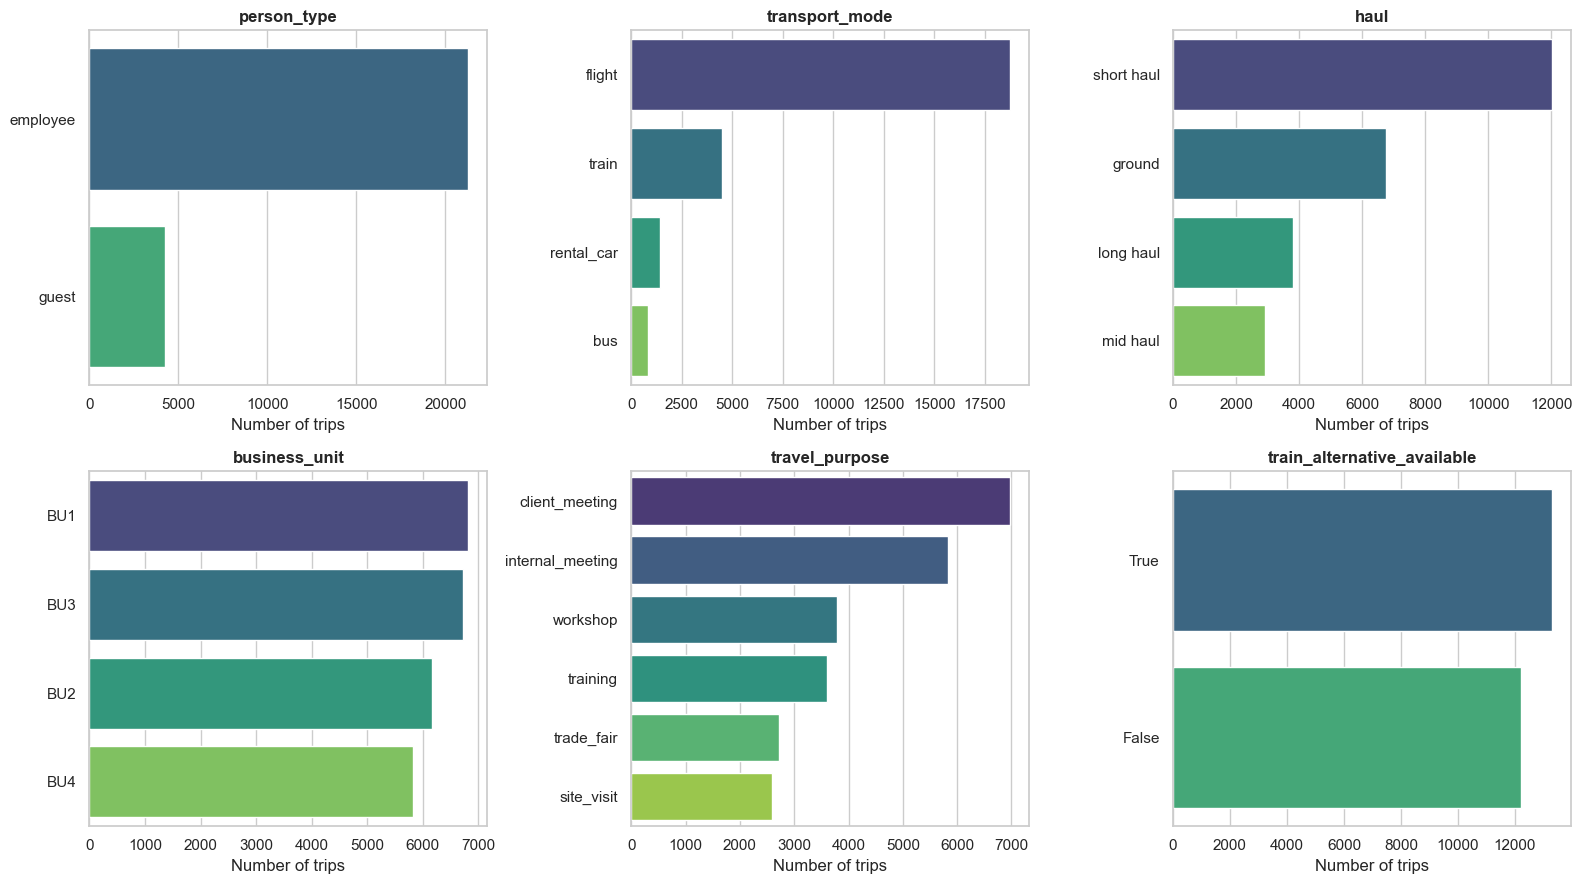

In [9]:
cat_cols = ['person_type', 'transport_mode', 'haul', 'business_unit',
            'travel_purpose', 'train_alternative_available']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax,
                hue=counts.index.astype(str), legend=False, palette='viridis')
    ax.set_title(col)
    ax.set_xlabel('Number of trips')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.2 Numerical Variables

Due to strongly skewed distributions (long tail for distance/CO₂/cost), we use boxplots on a log scale per transport mode.

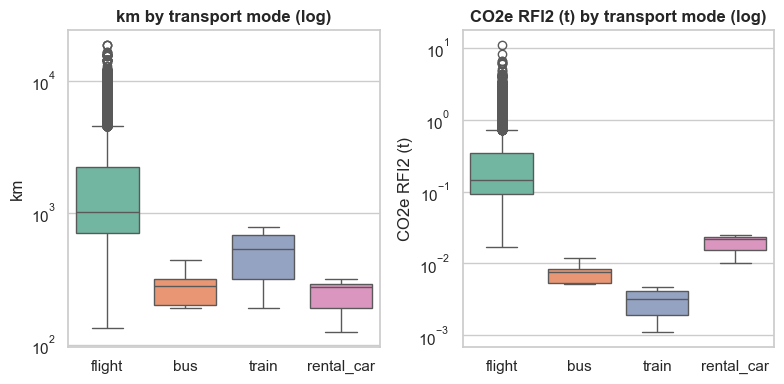

In [10]:
num_cols = ['km', 'CO2e RFI2 (t)']

# Boxplots of the numerical variables per transport mode
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='transport_mode', y=col, ax=ax,
                hue='transport_mode', legend=False, palette='Set2')
    ax.set_yscale('log')
    ax.set_title(f'{col} by transport mode (log)')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 5. Time Development

We aggregate on a yearly and monthly level to identify trends and seasonal patterns.

In [11]:
df['year'] = df['date'].dt.year
df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()

## 6. Bivariate / Multivariate Relationships

### 6.1 CO₂ and Costs per Business Unit

In [12]:
by_bu = df.groupby('business_unit').agg(
    trips=('date', 'count'),
    co2_t=('CO2e RFI2.7 (t)', 'sum'),
    cost_CHF=('cost_CHF', 'sum'),
    km=('km', 'sum'),
).round(1).sort_index()
by_bu

,trips,co2_t,cost_CHF,km
business_unit,,,,
BU1,6821,2594.8,4662994.7,11918684
BU2,6164,2640.4,4619300.6,11877447
BU3,6719,3232.0,5438013.5,14137101
BU4,5823,2360.7,4171571.8,10689503


### 6.2 Travel Purpose and Transport Mode

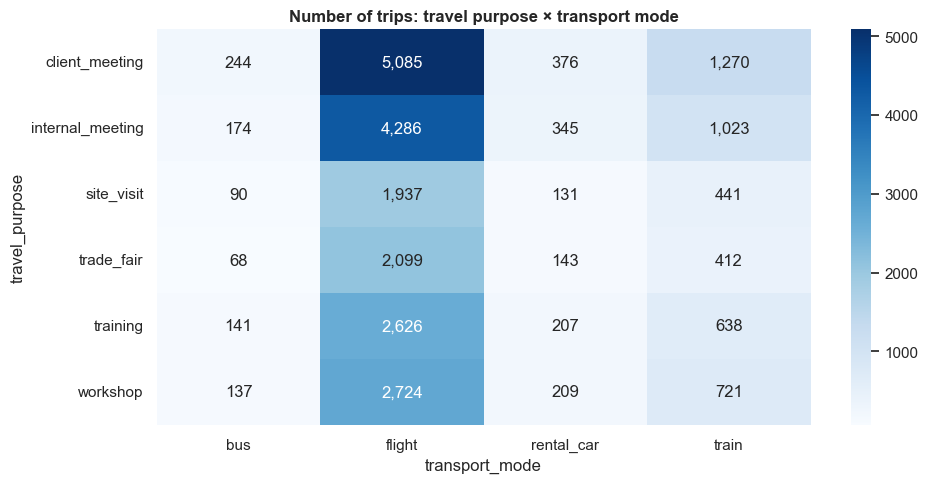

In [13]:
purpose_mode = pd.crosstab(df['travel_purpose'], df['transport_mode'])
plt.figure(figsize=(10, 5))
sns.heatmap(purpose_mode, annot=True, fmt=',d', cmap='Blues')
plt.title('Number of trips: travel purpose × transport mode')
plt.tight_layout()
plt.show()

### 6.3 Train Alternative Available – But Flight Taken?

A particularly interesting question: how many flights were booked despite an available train connection? (`train_alternative_available == True` & `transport_mode == 'flight'`)

In [14]:
flights_with_train = df[(df['transport_mode'] == 'flight') &
                        (df['train_alternative_available'] == True)]
all_flights = df[df['transport_mode'] == 'flight']

share = len(flights_with_train) / len(all_flights) * 100
print(f'Flights with available train alternative: {len(flights_with_train):,} '
      f'of {len(all_flights):,} ({share:.1f} %)')
print(f"Avoidable CO₂ emissions (RFI2.7): {flights_with_train['CO2e RFI2.7 (t)'].sum():.1f} t")
print(f"Avoidable costs:                  {flights_with_train['cost_CHF'].sum():,.0f} CHF")

Flights with available train alternative: 6,530 of 18,757 (34.8 %)
Avoidable CO₂ emissions (RFI2.7): 753.5 t
Avoidable costs:                  2,880,568 CHF


C:\Users\PC-Domenik-2\AppData\Local\Temp\ipykernel_20084\843065039.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\ZHAW\ad24-7-fancyproject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


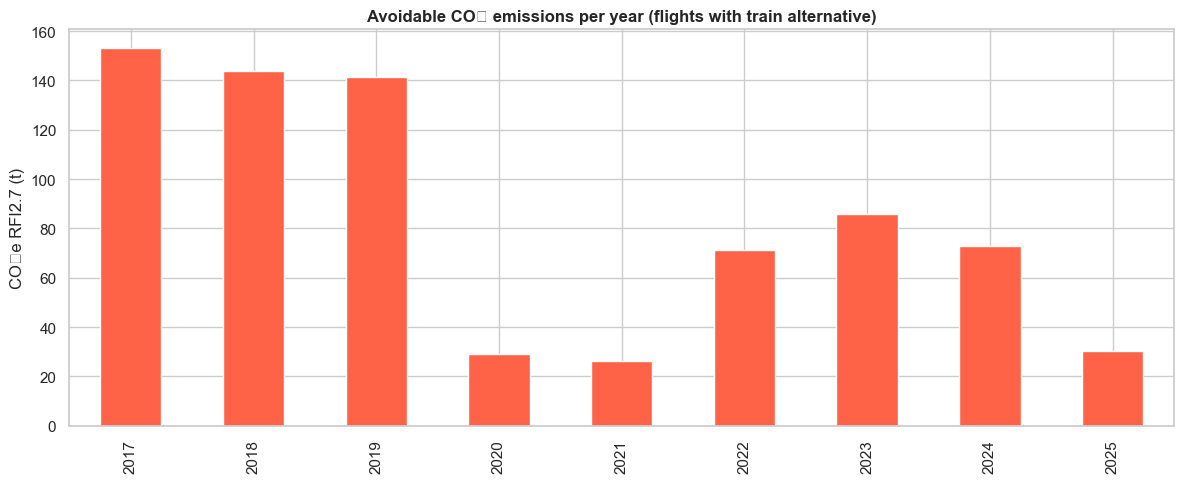

In [15]:
# Over the years
avoidable = (flights_with_train.groupby('year')
             .agg(trips=('date', 'count'),
                  co2_t=('CO2e RFI2.7 (t)', 'sum'),
                  cost_CHF=('cost_CHF', 'sum')))

fig, ax = plt.subplots(figsize=(12, 5))
avoidable['co2_t'].plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Avoidable CO₂ emissions per year (flights with train alternative)')
ax.set_ylabel('CO₂e RFI2.7 (t)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 7. Geographical Analysis

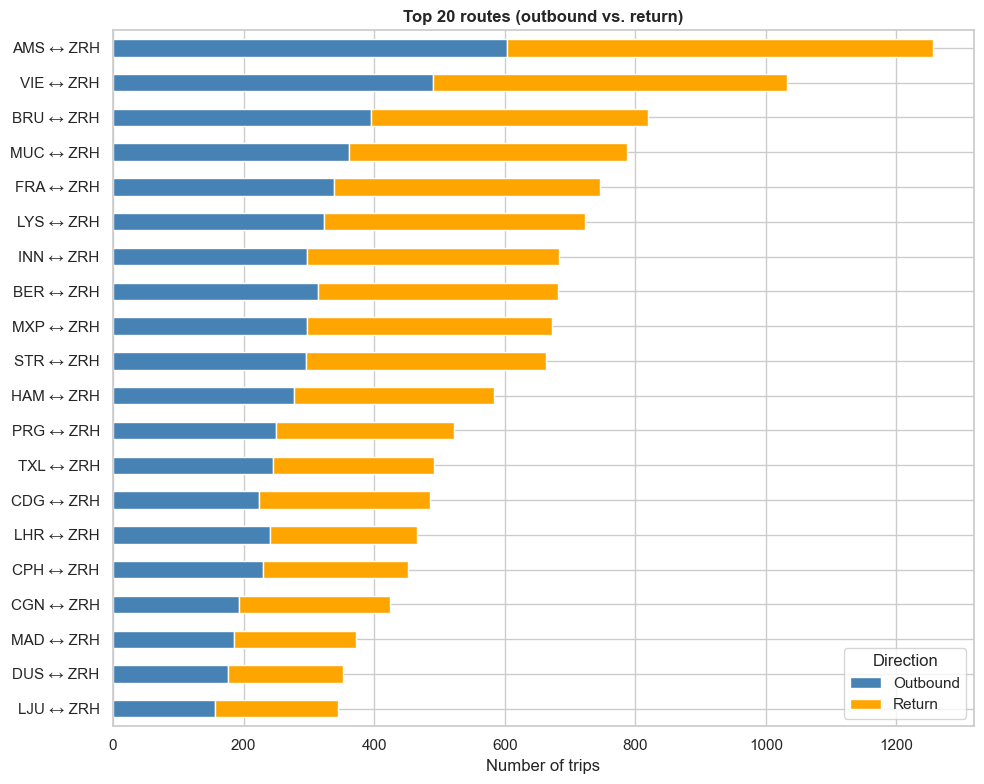

In [16]:
# Canonical route (alphabetically sorted) and direction
df['route'] = df['departure_iata'] + ' → ' + df['arrival_iata']
df['route_pair'] = df.apply(
    lambda r: ' ↔ '.join(sorted([r['departure_iata'], r['arrival_iata']])), axis=1
)
df['direction'] = df.apply(
    lambda r: 'Outbound' if r['departure_iata'] <= r['arrival_iata'] else 'Return', axis=1
)

# Top 20 route pairs by total count
top_pairs = df['route_pair'].value_counts().head(20).index
df_top = df[df['route_pair'].isin(top_pairs)]

# Pivot: route pairs × direction
pivot = (
    df_top.groupby(['route_pair', 'direction']).size()
          .unstack(fill_value=0)
          .loc[top_pairs]
)

# Stacked horizontal bar chart
ax = pivot.plot(kind='barh', stacked=True, figsize=(10, 8),
                color=['steelblue', 'orange'])
ax.set_title('Top 20 routes (outbound vs. return)')
ax.set_xlabel('Number of trips')
ax.set_ylabel('')
ax.invert_yaxis()
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

## 8. CO₂ Budget Comparison

We compare the actual CO₂ emissions with the stored CO₂ budgets per subunit (sheet `co2_budgets`) and the 2026 budget overview.

In [17]:
print('budget_2026 (overview):')
display(budget_2026)

budget_2026 (overview):


,Business Unit,2024,2025,2026 (Prognose)
0,BU1,"253,7","230,6","207,5"
1,BU2,"258,5",235,"211,5"
2,BU3,"294,5","267,7","240,9"
3,BU4,"220,8","200,6","181,2"
4,Total,"1.027,50","933,9","841,1"


In [18]:
# CO2 per business unit & year vs. budget (aggregated to BU level)
actual_bu_year = (df.groupby(['business_unit', 'year'])['CO2e RFI2.7 (t)']
                    .sum().reset_index(name='actual_co2_t'))

# Subunit X.Y -> BU X (assumption)
co2_budgets_bu = co2_budgets.copy()
co2_budgets_bu['business_unit'] = ('BU' + co2_budgets_bu['subunit']
                                   .str.extract(r'Subunit (\d)')[0])
budget_bu_year = (co2_budgets_bu.groupby(['business_unit', 'year'])['co2_budget_t']
                                 .sum(min_count=1).reset_index())

comparison = actual_bu_year.merge(budget_bu_year, on=['business_unit', 'year'], how='left')
comparison.head()

,business_unit,year,actual_co2_t,co2_budget_t
0,BU1,2017,341.5022,NaN
1,BU1,2018,344.8364,NaN
2,BU1,2019,483.1885,NaN
3,BU1,2020,115.8244,329.4
4,BU1,2021,35.5168,329.4


c:\ZHAW\ad24-7-fancyproject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\ZHAW\ad24-7-fancyproject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


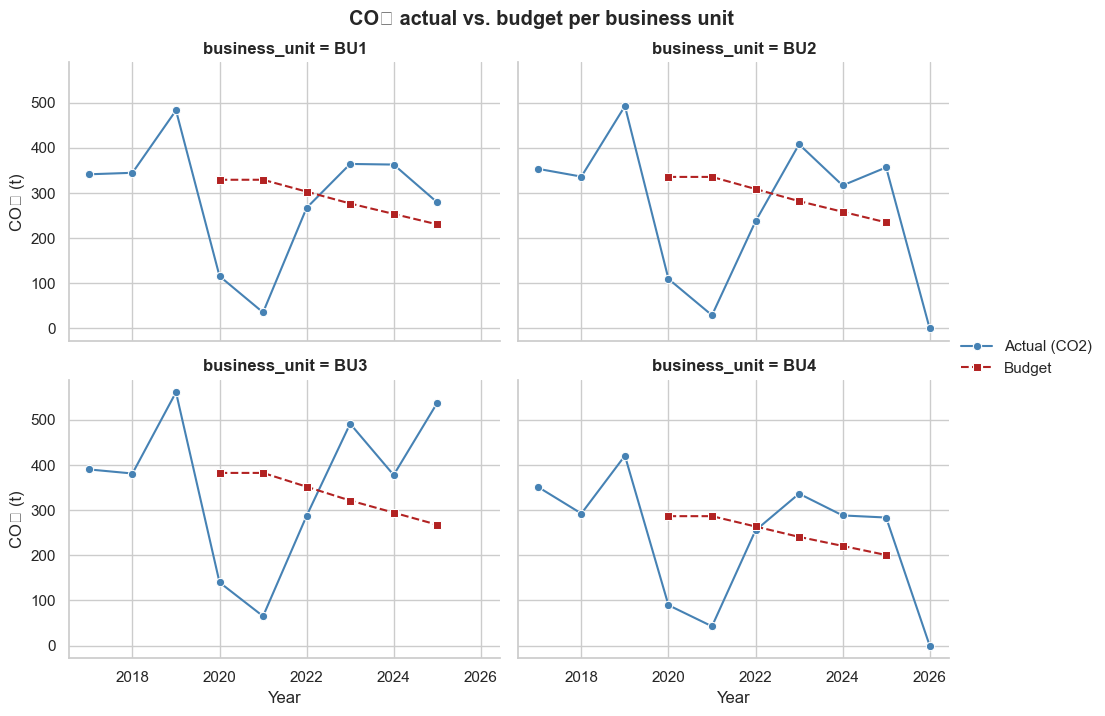

In [19]:
g = sns.FacetGrid(comparison, col='business_unit', col_wrap=2, height=3.5, aspect=1.4)
g.map_dataframe(sns.lineplot, x='year', y='actual_co2_t',
                marker='o', label='Actual (CO2)', color='steelblue')
g.map_dataframe(sns.lineplot, x='year', y='co2_budget_t',
                marker='s', label='Budget', color='firebrick', linestyle='--')
g.set_axis_labels('Year', 'CO₂ (t)')
g.add_legend()
g.fig.suptitle('CO₂ actual vs. budget per business unit', y=1.02, fontweight='bold')
plt.show()